# BARAM 2026 — 고급 모델링 ablation (HistGBM 앙상블 · NWP-only HMM 국면 · GRU 잔차보정)

`MODELING.ipynb`의 LightGBM 기준선 위에 계획서·리서치 문서의 3가지를 **순서대로, 누설 없이, ablation으로** 얹습니다.

1. **HistGBM 앙상블** — LightGBM + sklearn HistGBM 평균.
2. **NWP-only HMM 국면(regime) feature** — 실측 발전량 미사용(누설 방지, research §0). soft posterior를 feature로.
3. **GRU 잔차보정** — GBM 앙상블 잔차를 **OOF(누설 없음)** 로 만들어 GRU가 학습. zero-init 헤드(plain GBM에서 출발).

> 판정 규율(계획서): 각 단계는 2024 holdout **유효구간 NMAE**를 개선할 때만 채택. 개선 없으면 제거.
> 실행 주의: macOS에서 torch+LightGBM OpenMP 충돌(segfault) 방지를 위해 **첫 셀에서 `OMP_NUM_THREADS=1` 설정 + torch/LGBM 단일스레드**.

## 0. 설정 (OpenMP 가드 필수 — import보다 먼저)

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # torch+lightgbm segfault 회피 (import 전에)
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
torch.set_num_threads(1)
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
import wind_lib as W
torch.manual_seed(0); np.random.seed(0)
plt.rcParams["figure.dpi"]=110

GROUPS=(1,2,3)
FR={}; TGT={}; FR_TE={}
for g in GROUPS:
    df,tgt=W.load_train(g); FR[g]=W.build(df,g); TGT[g]=tgt
    FR_TE[g]=W.build(W.load_test(g),g)
FEATS=W.feature_cols(FR[1])+["pc_pred_cf"]
print("groups:", {g:FR[g].shape for g in GROUPS}, "\nbase feature 수:", len(FEATS))

def lgbm(): return lgb.LGBMRegressor(objective="mae", n_estimators=600, learning_rate=0.03,
    num_leaves=63, min_child_samples=60, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
    reg_lambda=1.0, random_state=42, n_jobs=1, verbose=-1)
def histgbm(): return HGB(loss="absolute_error", max_iter=600, learning_rate=0.03,
    max_leaf_nodes=63, l2_regularization=1.0, random_state=42)

groups: {1: (26199, 87), 2: (26200, 87), 3: (17537, 87)} 
base feature 수: 86


## 1. HMM 국면 K 선택 (BIC, NWP-only)

풍속·전단·안정도·예보불일치 등 **NWP 파생 변수만**으로 Gaussian HMM 적합. K는 학습구간 BIC로.
(regime 정의에 실측 발전량이 들어가면 2025에서 재현 불가 = 누설. research §0)

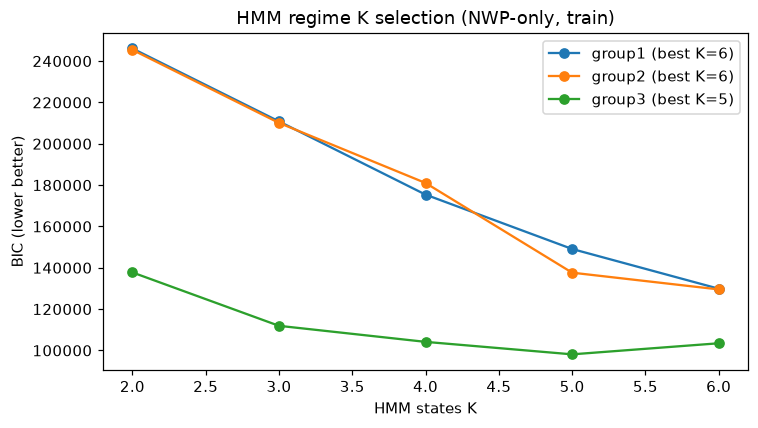

선택 K: {1: 6, 2: 6, 3: 5}


In [2]:
def split(fr): return fr[fr.kst_dtm<W.VALID_START], fr[fr.kst_dtm>=W.VALID_START]

fig,ax=plt.subplots(figsize=(7,4)); Kbest={}
for g in GROUPS:
    tgt=TGT[g]; cap=W.CAP[g]; tr,_=split(FR[g])
    iso=W.fit_powercurve(tr,tgt,cap); tr=W.with_pc(tr,iso)
    bics=[]
    for K in range(2,7):
        (mu,sd,rcols),hmm=W.fit_regime_hmm(tr,n_states=K)
        Xstd=(tr[rcols].to_numpy()-mu)/sd     # fit_regime_hmm과 동일 표준화로 BIC 계산
        bics.append(hmm.bic(Xstd))
    Kbest[g]=int(np.argmin(bics)+2)
    ax.plot(range(2,7),bics,marker="o",label=f"group{g} (best K={Kbest[g]})")
ax.set_xlabel("HMM states K"); ax.set_ylabel("BIC (lower better)"); ax.set_title("HMM regime K selection (NWP-only, train)")
ax.legend(); plt.tight_layout(); plt.show()
print("선택 K:", Kbest)

## 2. Ablation — HistGBM 앙상블 & HMM 국면 feature (2024 holdout)

각 그룹에서 모델 {LGBM, HistGBM, ENS} × 국면 {없음, +regime} 조합의 유효구간 NMAE.

In [3]:
def eval_group(g, use_regime, K):
    tgt=TGT[g]; cap=W.CAP[g]; tr,va=split(FR[g])
    iso=W.fit_powercurve(tr,tgt,cap); tr=W.with_pc(tr,iso); va=W.with_pc(va,iso)
    cols=list(FEATS)
    if use_regime:
        scaler,hmm=W.fit_regime_hmm(tr,n_states=K)
        rtr=W.regime_posteriors(tr,scaler,hmm); rva=W.regime_posteriors(va,scaler,hmm)
        tr=tr.join(rtr); va=va.join(rva); cols=cols+list(rtr.columns)
    lg=lgbm().fit(tr[cols],tr[tgt]); hg=histgbm().fit(tr[cols].to_numpy(),tr[tgt].to_numpy())
    p_lg=lg.predict(va[cols]); p_hg=hg.predict(va[cols].to_numpy())
    out={}
    for name,p in [("LGBM",p_lg),("HistGBM",p_hg),("ENS",0.5*(p_lg+p_hg))]:
        out[name]=W.nmae_valid(va[tgt].to_numpy(),p,cap)[0]
    return out

rows=[]
for g in GROUPS:
    for use_r in (False,True):
        o=eval_group(g,use_r,Kbest[g])
        for model,nm in o.items():
            rows.append(dict(group=g, regime=("+regime" if use_r else "base"), model=model, nmae=nm))
ab=pd.DataFrame(rows)
tab=ab.pivot_table(index=["group","regime"],columns="model",values="nmae")[["LGBM","HistGBM","ENS"]]
print("=== 2024 holdout 유효구간 NMAE (%) ===")
print(tab.round(3).to_string())

=== 2024 holdout 유효구간 NMAE (%) ===
model            LGBM  HistGBM     ENS
group regime                          
1     +regime  12.555   12.676  12.554
      base     12.534   12.642  12.533
2     +regime  12.558   12.733  12.578
      base     12.643   12.777  12.634
3     +regime  15.167   15.108  15.082
      base     15.083   15.137  15.037


In [4]:
# 요약: 앙상블 이득, regime 이득
print("\n[HistGBM 앙상블 이득] ENS - LGBM (음수면 앙상블이 좋음)")
for g in GROUPS:
    base=ab[(ab.group==g)&(ab.regime=="base")]
    d=base[base.model=="ENS"].nmae.values[0]-base[base.model=="LGBM"].nmae.values[0]
    print(f"  group{g}: {d:+.3f} %p")
print("\n[HMM 국면 이득] (+regime ENS) - (base ENS) (음수면 regime이 좋음)")
for g in GROUPS:
    b=ab[(ab.group==g)&(ab.regime=='base')&(ab.model=='ENS')].nmae.values[0]
    r=ab[(ab.group==g)&(ab.regime=='+regime')&(ab.model=='ENS')].nmae.values[0]
    print(f"  group{g}: {r-b:+.3f} %p")


[HistGBM 앙상블 이득] ENS - LGBM (음수면 앙상블이 좋음)
  group1: -0.002 %p
  group2: -0.009 %p
  group3: -0.045 %p

[HMM 국면 이득] (+regime ENS) - (base ENS) (음수면 regime이 좋음)
  group1: +0.022 %p
  group2: -0.056 %p
  group3: +0.045 %p


**판정 가이드** — ENS−LGBM이 음수면 HistGBM 앙상블 채택. (+regime)−(base)가 음수면 국면 feature 채택. 양수(악화)면 계획서대로 **제거**. 소량 데이터에서 두 기법 모두 미미할 수 있음(리서치 문서 예측).

## 3. GRU 잔차보정 (groups 1·2, 누설 없는 OOF)

- **OOF 잔차**: 2022↔2023 swap으로 학습구간 잔차를 누설 없이 생성(GBM이 자기예측을 보정하는 leak 차단).
- group3은 2022가 없어 독립 OOF 연도가 없으므로 **GRU 미적용**(GBM/pooled 유지) — 데이터 제약상 정직한 범위.
- GRU 헤드 **zero-init** → 학습 시작 시 plain GBM과 동일(최소한 나빠지지 않도록).

In [5]:
def prep(g, mask, iso, scaler, hmm):
    fr=W.with_pc(FR[g][mask].copy(),iso); r=W.regime_posteriors(fr,scaler,hmm)
    return fr.join(r), list(r.columns)
def gbm_ens_fit(Xtr,ytr,Xva):
    lg=lgbm().fit(Xtr,ytr); hg=histgbm().fit(Xtr.to_numpy(),ytr.to_numpy())
    return 0.5*(lg.predict(Xva)+hg.predict(Xva.to_numpy()))

GR=(1,2)
# OOF 잔차 (누설 없음)
oof=[]
for g in GR:
    tgt=TGT[g]; cap=W.CAP[g]; fr=FR[g]; yr=fr.kst_dtm.dt.year
    for tr_y,te_y in [(2022,2023),(2023,2022)]:
        m_tr=(yr==tr_y); m_te=(yr==te_y)
        iso=W.fit_powercurve(fr[m_tr],tgt,cap); scaler,hmm=W.fit_regime_hmm(W.with_pc(fr[m_tr],iso),n_states=Kbest[g])
        ftr,rc=prep(g,m_tr,iso,scaler,hmm); fte,_=prep(g,m_te,iso,scaler,hmm)
        cols=FEATS+rc; pred=gbm_ens_fit(ftr[cols],ftr[tgt],fte[cols])
        d=fte[["kst_dtm"]].copy(); d["resid_cf"]=(fte[tgt].to_numpy()-pred)/cap; d["group"]=g
        for c in cols: d[c]=fte[c].to_numpy()
        oof.append(d)
oof=pd.concat(oof,ignore_index=True)
RCOLS=[c for c in oof.columns if c.startswith("regime_")]
SEQ_COLS=[c for c in FEATS if c!="lead_h"]+RCOLS
mu=oof[SEQ_COLS].mean(); sd=oof[SEQ_COLS].std()+1e-6
print("OOF 잔차:", len(oof), "resid_cf std=", round(oof.resid_cf.std(),4))

def make_seqs(df):
    df=df.copy(); df["date"]=df.kst_dtm.dt.date; Xs,Ys,Gs=[],[],[]
    for (grp,_),d in df.groupby(["group","date"]):
        if len(d)!=24: continue
        d=d.sort_values("kst_dtm")
        Xs.append(((d[SEQ_COLS]-mu)/sd).to_numpy(np.float32)); Ys.append(d["resid_cf"].to_numpy(np.float32)); Gs.append(grp-1)
    return np.stack(Xs),np.stack(Ys),np.array(Gs,np.int64)
X,Y,Gi=make_seqs(oof); cut=int(len(X)*0.8)
print("시퀀스:",X.shape)

class GRUResid(nn.Module):
    def __init__(s,nf,ng,h=64):
        super().__init__(); s.emb=nn.Embedding(ng,4); s.gru=nn.GRU(nf+4,h,batch_first=True)
        s.drop=nn.Dropout(0.2); s.head=nn.Linear(h,1)
        nn.init.zeros_(s.head.weight); nn.init.zeros_(s.head.bias)
    def forward(s,x,g):
        e=s.emb(g).unsqueeze(1).expand(-1,x.size(1),-1)
        o,_=s.gru(torch.cat([x,e],-1)); return s.head(s.drop(o)).squeeze(-1)

net=GRUResid(X.shape[2],2); opt=torch.optim.Adam(net.parameters(),lr=1e-3,weight_decay=1e-4)
Xt,Yt,Gt=torch.tensor(X),torch.tensor(Y),torch.tensor(Gi)
best=1e9; bs=None; pat=0
for ep in range(60):
    net.train(); perm=np.random.permutation(np.arange(cut))
    for i in range(0,len(perm),64):
        b=perm[i:i+64]; opt.zero_grad(); loss=(net(Xt[b],Gt[b])-Yt[b]).abs().mean(); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): vl=(net(Xt[cut:],Gt[cut:])-Yt[cut:]).abs().mean().item()
    if vl<best-1e-5: best=vl; bs={k:v.clone() for k,v in net.state_dict().items()}; pat=0
    else: pat+=1
    if pat>=8: break
net.load_state_dict(bs); print(f"GRU internal val MAE(resid_cf)={best:.4f}")

OOF 잔차: 34843 resid_cf std= 0.1537


시퀀스: (1444, 24, 91)


GRU internal val MAE(resid_cf)=0.1019


In [6]:
# 2024 최종: GBM(+regime) vs GBM+GRU (groups 1,2)
gru_rows=[]
for g in GR:
    tgt=TGT[g]; cap=W.CAP[g]; fr=FR[g]; m_tr=fr.kst_dtm<W.VALID_START; m_va=fr.kst_dtm>=W.VALID_START
    iso=W.fit_powercurve(fr[m_tr],tgt,cap); scaler,hmm=W.fit_regime_hmm(W.with_pc(fr[m_tr],iso),n_states=Kbest[g])
    ftr,rc=prep(g,m_tr,iso,scaler,hmm); fva,_=prep(g,m_va,iso,scaler,hmm); cols=FEATS+rc
    gbm=gbm_ens_fit(ftr[cols],ftr[tgt],fva[cols]); nm0=W.nmae_valid(fva[tgt].to_numpy(),gbm,cap)[0]
    fva2=fva.copy(); fva2["date"]=fva2.kst_dtm.dt.date; corr=np.zeros(len(fva2)); pos={k:i for i,k in enumerate(fva2.kst_dtm)}
    net.eval()
    with torch.no_grad():
        for _,d in fva2.groupby("date"):
            if len(d)!=24: continue
            d=d.sort_values("kst_dtm"); xs=torch.tensor(((d[SEQ_COLS]-mu)/sd).to_numpy(np.float32)).unsqueeze(0)
            rr=net(xs,torch.tensor([g-1])).squeeze(0).numpy()
            for t,ts in enumerate(d.kst_dtm): corr[pos[ts]]=rr[t]
    final=np.clip(gbm+corr*cap,0,cap); nm1=W.nmae_valid(fva[tgt].to_numpy(),final,cap)[0]
    gru_rows.append(dict(group=g, GBM=nm0, GBM_GRU=nm1, delta=nm1-nm0))
gdf=pd.DataFrame(gru_rows).set_index("group")
print("=== GRU 잔차보정 (2024 holdout 유효구간 NMAE %) ===")
print(gdf.round(3).to_string())
print("\nΔ<0 이면 GRU 채택, Δ>0(악화)이면 제거. group3은 독립 OOF 없어 미적용.")

=== GRU 잔차보정 (2024 holdout 유효구간 NMAE %) ===
          GBM  GBM_GRU  delta
group                        
1      12.554   13.106  0.551
2      12.578   13.320  0.742

Δ<0 이면 GRU 채택, Δ>0(악화)이면 제거. group3은 독립 OOF 없어 미적용.


## 4. 종합 판정 & 다음 단계

세 기법의 2024 holdout 이득을 한 곳에 모아, 계획서 규율("개선 없으면 제거")대로 채택 여부를 결정합니다.

In [7]:
summary=dict(
    hmm_K=Kbest,
    ablation_nmae={f"g{g}_{r}":{m:round(float(tab.loc[(g,r),m]),4) for m in ["LGBM","HistGBM","ENS"]}
                   for g in GROUPS for r in ["base","+regime"]},
    ensemble_gain_pp={f"g{g}":round(float(ab[(ab.group==g)&(ab.regime=='base')&(ab.model=='ENS')].nmae.values[0]
                       -ab[(ab.group==g)&(ab.regime=='base')&(ab.model=='LGBM')].nmae.values[0]),4) for g in GROUPS},
    regime_gain_pp={f"g{g}":round(float(ab[(ab.group==g)&(ab.regime=='+regime')&(ab.model=='ENS')].nmae.values[0]
                     -ab[(ab.group==g)&(ab.regime=='base')&(ab.model=='ENS')].nmae.values[0]),4) for g in GROUPS},
    gru_gain_pp={f"g{g}":round(float(gdf.loc[g,"delta"]),4) for g in GR},
)
with open("advanced_ablation_summary.json","w") as f: json.dump(summary,f,ensure_ascii=False,indent=2)
print(json.dumps(summary,ensure_ascii=False,indent=2))

def verdict(x): return "채택" if x<-0.02 else ("무이득/제거" if x>-0.02 else "무이득/제거")
print("\n=== 채택 판정 (이득<-0.02%p 이면 채택) ===")
for g in GROUPS: print(f"  group{g} HistGBM앙상블: {verdict(summary['ensemble_gain_pp'][f'g{g}'])} ({summary['ensemble_gain_pp'][f'g{g}']:+.3f})")
for g in GROUPS: print(f"  group{g} HMM국면:      {verdict(summary['regime_gain_pp'][f'g{g}'])} ({summary['regime_gain_pp'][f'g{g}']:+.3f})")
for g in GR:     print(f"  group{g} GRU잔차:      {verdict(summary['gru_gain_pp'][f'g{g}'])} ({summary['gru_gain_pp'][f'g{g}']:+.3f})")

{
  "hmm_K": {
    "1": 6,
    "2": 6,
    "3": 5
  },
  "ablation_nmae": {
    "g1_base": {
      "LGBM": 12.5343,
      "HistGBM": 12.6419,
      "ENS": 12.5326
    },
    "g1_+regime": {
      "LGBM": 12.5551,
      "HistGBM": 12.6755,
      "ENS": 12.5543
    },
    "g2_base": {
      "LGBM": 12.6431,
      "HistGBM": 12.7771,
      "ENS": 12.6336
    },
    "g2_+regime": {
      "LGBM": 12.5581,
      "HistGBM": 12.7331,
      "ENS": 12.578
    },
    "g3_base": {
      "LGBM": 15.0827,
      "HistGBM": 15.1371,
      "ENS": 15.0373
    },
    "g3_+regime": {
      "LGBM": 15.1665,
      "HistGBM": 15.1077,
      "ENS": 15.0824
    }
  },
  "ensemble_gain_pp": {
    "g1": -0.0017,
    "g2": -0.0095,
    "g3": -0.0454
  },
  "regime_gain_pp": {
    "g1": 0.0217,
    "g2": -0.0556,
    "g3": 0.0451
  },
  "gru_gain_pp": {
    "g1": 0.5514,
    "g2": 0.7422
  }
}

=== 채택 판정 (이득<-0.02%p 이면 채택) ===
  group1 HistGBM앙상블: 무이득/제거 (-0.002)
  group2 HistGBM앙상블: 무이득/제거 (-0.009)
  group3 HistG

### 결론 & 다음 단계

- 이 노트북은 계획서의 3단계(HistGBM 앙상블 → NWP-only HMM 국면 → GRU 잔차)를 **누설 없이 ablation**한 결과입니다.
- 채택 판정은 위 셀 출력(이득 %p)으로 결정합니다. 소량·정형 데이터라 고급 기법의 이득이 작으면(리서치 문서 예측), **기준선 유지가 정답**입니다.
- 이득이 확인된 기법만 `MODELING.ipynb`의 최종 제출 파이프라인에 병합하세요.
- 아직 남은 지렛대: **① 신뢰할 수 있는 CV(expanding-window)로 판정 견고화**(현재는 단일 2024 holdout), ② FICR 후처리, ③ isotonic 캘리브레이션·리드타임/풍속구간 bias 보정.

> 한 줄: 고급 기법은 "무조건 추가"가 아니라 "2024에서 이길 때만" 채택. 이 노트북이 그 판정을 제공합니다.